Elbette! Şimdi sınıflandırmadan farklı bir dünyaya geçiyorsun:

## 🟣 **Clustering (Kümeleme)**

Bu bölümde artık **etiketli veri (sınıf)** olmadan, yani **denetimsiz öğrenme (unsupervised learning)** yapacaksın.
İlk konun:

## 📌 **K-Means Clustering** – En popüler kümeleme algoritması

---

### 📌 Kısaca: Nedir Bu K-Means?

**K-Means**, veriyi `K` sayıda gruba (küme) ayıran bir algoritmadır.

> Hangi veri noktaları birbiriyle benzer?
> Verileri grupla, ama **önceden sınıf bilgisi (etiket)** yok!

---

## 🔢 Nasıl Çalışır? (Adım Adım)

1. **K küme sayısı belirlenir** (örneğin `K=3`)
2. **Rastgele K tane merkez (centroid)** seçilir
3. Her veri noktası, en yakın merkeze atanır → kümeler oluşur
4. Her küme için **yeni merkez** hesaplanır (küme içi ortalama)
5. Adımlar tekrar edilir → merkezler değişmiyorsa dur

Bu işleme **"K-Means Iterasyonu"** denir.

---

## 📈 Görsel Mantığı:

Veriler şöyle dağılmışsa:

```
● ● ●       ○ ○ ○       ■ ■ ■
```

K-Means:

* Bu noktaları gruplayacak
* Her grubun ortasını bulacak
* Sonra ona en yakınları yeniden toplayacak

---

## ✅ Avantajları:

| Avantaj            | Açıklama                                 |
| ------------------ | ---------------------------------------- |
| ✅ Basit ve hızlı   | Büyük veri setlerinde bile çalışır       |
| ✅ Yorumu kolay     | Görselleştirmesi çok sezgiseldir         |
| ✅ Önişlemeye uygun | Özellik ölçeklemesi ile güçlü hale gelir |

---

## ⚠️ Dezavantajları:

| Dezavantaj                   | Açıklama                                      |
| ---------------------------- | --------------------------------------------- |
| ❌ K değeri önceden bilinmeli | Kaç küme olacağını sen belirlemelisin         |
| ❌ Aykırı değer duyarlılığı   | Outlier'lar küme merkezini bozabilir          |
| ❌ Küme şekli dairesel olmalı | Karmaşık şekilli kümelerde başarısız olabilir |

---

## 🔍 En Sık Sorulan Soru:

### ❓ K değeri nasıl seçilir?

* **Elbow Method (Dirsek Yöntemi)**
  → Küme içi varyans (WCSS) vs K çizilir
  → Grafik "dirsek yaptığı" yerde K seçilir

---

## 💻 Python Kullanımı:

```python
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)

y_kmeans = kmeans.predict(X)
```

---

## 📊 Değerlendirme:

* `inertia_` → Küme içi toplam hata kareleri (WCSS)
* `kmeans.cluster_centers_` → Merkezlerin koordinatları
* `kmeans.labels_` → Hangi veri hangi kümeye ait

---

## 🎓 Özetle:

| Özellik           | Açıklama                                      |
| ----------------- | --------------------------------------------- |
| Denetimsiz mi?    | ✅ Evet (etiket yok)                           |
| K girişi şart mı? | ✅ Evet (önceden belirlenmeli)                 |
| Ne işe yarar?     | Veri segmentasyonu, desen keşfi, grup analizi |

---

Video sonrasında birlikte Elbow yöntemi ile doğru K'yi seçip görselleştirme yapabiliriz (2D veya 3D veri ile).
Sonraki videolarda muhtemelen **Hierarchical Clustering** veya **DBSCAN** gelecektir. Hazır olduğunda haber ver!

Evet, çok güzel bir yere değindin! Çünkü K-Means algoritmasının başarısı büyük oranda **ilk merkezlerin nasıl seçildiğine** bağlıdır.
İşte bu yüzden **K-Means++** geliştirilmiştir.

---

## 🔷 K-Means++ Nedir?

**K-Means++**, klasik K-Means’teki “rastgele merkez seçimi” problemini düzeltmek için kullanılan bir **merkez başlatma (initialization) tekniğidir**.

> Yani: İlk kümelerin merkezlerini **daha akıllıca** seçer.
> Böylece **daha iyi kümeler**, **daha az iterasyon**, **daha az hata** sağlar.

---

## 📉 Sorun: K-Means’in Rastgele Başlatması

K-Means klasik algoritmada:

* K merkez **rastgele** seçilir
* Kötü bir başlangıç → kötü kümeler, sapmış sonuçlar

🔴 Özellikle şöyle sorunlar yaşanabilir:

* Tüm merkezler yakın yerlere düşebilir
* Bazı kümeler boş kalabilir
* Aykırı merkezler yüzünden dengesiz bölünmeler oluşabilir

---

## ✅ Çözüm: K-Means++ Nasıl Çalışır?

K-means++ merkezleri **daha dengeli dağıtarak** seçer. İşte adımları:

### 🧠 K-Means++ Başlatma Adımları:

1. İlk merkez **rastgele** seçilir
2. Diğer her nokta için bu merkeze olan **kare mesafesi** hesaplanır
3. Bu mesafeye **orantılı şekilde** yeni merkez seçilir → uzak olanların seçilme şansı artar
4. Tüm K merkez seçilene kadar devam edilir
5. Normal K-Means iterasyonları başlar

> 🔍 Yani: "Zaten seçilmiş merkezlere uzak olan noktaları seçme olasılığını artır"
> → Daha dengeli başlangıç, daha sağlam kümeleme

---

## 🔬 Teknik Fark:

| Özellik           | K-Means                    | K-Means++                        |
| ----------------- | -------------------------- | -------------------------------- |
| İlk merkez seçimi | Rastgele                   | Akıllı & uzaklık temelli         |
| Stabilite         | Düşük (çok değişken sonuç) | Yüksek (daha kararlı)            |
| Hız (ilk aşamada) | Daha hızlı                 | Biraz daha yavaş (ama değiyor)   |
| Sonuç kalitesi    | Tutarsız olabilir          | Genellikle daha doğru ve verimli |

---

## 💻 Python’da Zaten Varsayılan:

Scikit-learn’de `KMeans` zaten `init='k-means++'` olarak gelir:

```python
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=0)
kmeans.fit(X)
```

Yani `init='random'` yazmadıkça **K-Means++ kullanılıyor**.

---

## 🎓 Özetle:

* **K-Means++**, daha iyi kümeler için **akıllı merkez seçimi** yapar
* Klasik K-Means’in rastgelelik sorununu azaltır
* Daha hızlı **yakınsar (daha az iterasyon)** ve daha kararlı sonuçlar verir
* Scikit-learn’de **varsayılan ayardır**, ekstra uğraşmazsın

---

İstersen video sonrası aynı veri setinde `init='random'` ve `init='k-means++'` kullanarak farkları birlikte inceleyebiliriz.
Hazırsan sıradaki kümeleme modeline (muhtemelen Hierarchical veya DBSCAN) geçtiğinde de seni hazırlarım!



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset = pd.read_csv('Mall_Customers.csv')
#her satırda avm müşterisi ve onun hakkında toplanan değerler var ve 
#sonunda harcama skoru buluunmaktadır bu skoda göre harcama yapabilir yapamaz
X = dataset.iloc[:, [3, 4]].values #seçilen sütun indexleri verdik
#k means ta bağomlı değişken yoktur o yüzden x y diye ayırmıyoruz şimdilik
#Sırası iile sütunların gerekliliğinie bakarsak
#customerid'ye gerek yoktur sınıflandırma için
#bu sebepten annual income ve spending score yeterlidir **
# kümeleme yapacağımız için sadece spending skora göre yapılabilir

## Using the elbow method to find the optimal number of clusters

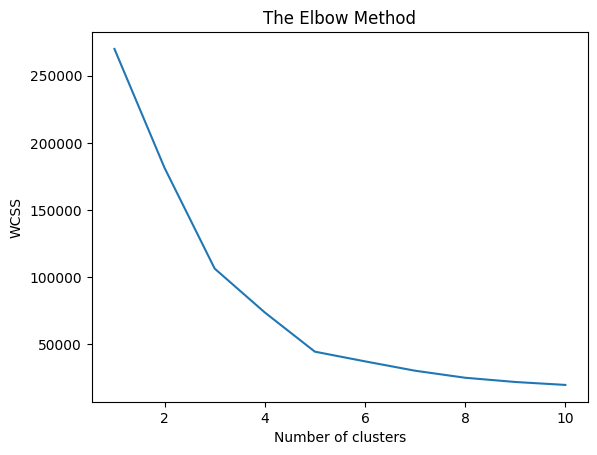

In [7]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X) #sadece özelliklere gerek olduğundan
    wcss.append(kmeans.inertia_) #intertia_ Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
# kaç tane clustor oluşturacağımızı tespit etmek için elbow methodunu uyguluyorus

## Training the K-Means model on the dataset

In [8]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

## Visualising the clusters

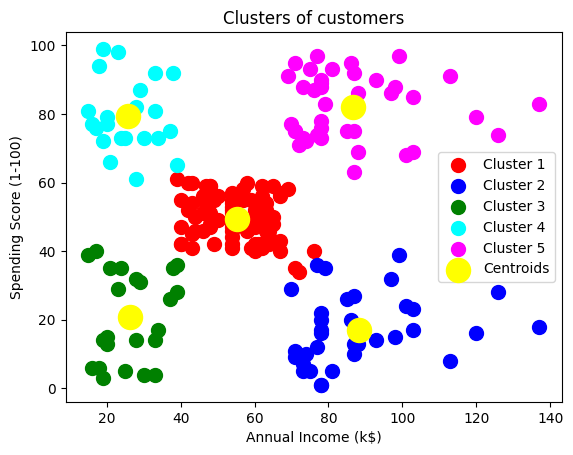

In [14]:
#birince satır açıklama
#X verisinde y_kmeans clusteri 0 olanlardan annual income satırı 0 index of x çizdiriyoruz
#İkinci x'de 1 indeksi X verisindeki yani spending dollar
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
#x ve y kordinatlarına göre cluster centerlerini yazdırıyoruz
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend() # bilgileri yazzar yanda kare içerisinde clusterleri
plt.show()

In [11]:
print(y_kmeans) #indexteki kişilerin clusterleri

[2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 0 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 4 1 4 0 4 1 4 1 4 0 4 1 4 1 4 1 4 1 4 0 4 1 4 1 4
 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4]


elde edilen grafik ile harcama ve gelir bazlı müşteriler hakkında stratejiler uygulanabilir